# Rename-proof logic consensus and error-type tests — demo of `method.py`

This notebook walks through `method.py` from experiment 8 (iteration 3) of the **gold-free NL→FOL metric** study. The study asks how to score a candidate first-order-logic (FOL) formalisation of a sentence **without a gold formula**.

**What the experiment does**
* **PEER_HYB consensus (our method).** A candidate formula is compared with *peer* formulas for the same sentence, produced by other LLM families. Two formulas agree when a z3-verified equivalence exists under **either** of two maps between their predicate names:
  * the **ALIGN** map, which matches predicates by name similarity;
  * the **NF-anchored** map, which matches them by structure and ignores names.

  `c_score = 1 − share of agreeing peers`. As with every score here, **higher means more likely an error**.
* **Part A.** A pre-registered rule selects a rename-invariant variant (HYB or NF). **Neither variant was eligible**: on PERTURB renames their false-alarm rates were far above 0.10. The final read therefore uses **ALIGN** (`c_score_align`).
* **Part B.** 27 gold-free metrics are scored on the **PERTURB** suite: typed mutants of trusted formulas (NEG, QUANT, SWAP, DROP, ADD, …) plus meaning-preserving controls (renames, De Morgan, reordering).
* **Output.** `build_output()` assembles `method_out.json` with four datasets: E candidates, the PERTURB suite, exp-D rewrites, and screen items and probes.

**What runs here.** The full pipeline has 13 stages. They are subprocess calls into the experiment's `src/` scripts, and they need z3, a 16 GB GPU for local judges and OpenRouter calls. That takes many hours and is **not** run in this notebook. The stage table and `run()` driver are shown unchanged. The final stage, **`build_output()`**, *is* run verbatim on a curated subset of its real input tables (`mini_demo_data.json`: 41 E rows from 3 sentences, 34 PERTURB rows and 17 screen/rewrite/probe rows). The notebook ends by summarising and plotting the resulting scores.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original `method.py` import block, unchanged, followed by the extra imports this notebook uses for the summary and plots.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- notebook-only additions (summary / visualisation) ---
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## Data loading
`mini_demo_data.json` bundles the subset of each source table that `build_output()` reads. Its keys mirror the original files: `results/per_item_hyb_E.jsonl`, `data/exp5/E_blind.jsonl`, `results/perturb_scores.jsonl`, `data/perturb_rows.jsonl`, `results/selection.json` and so on. The notebook fetches the file from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) for k, v in data.items() if isinstance(v, (list, dict))})

{'selection': 10, 'prereg_sha256': 2, 'analysis_perturb_metrics': 27, 'E_blind': 41, 'per_item_hyb_E': 41, 'perturb_scores': 34, 'perturb_rows': 33, 'screen_adjudicated_labels': 5, 'invariance_items': 6, 'screen_items': 9, 'screen_probes': 3, 'per_item_screen_hyb': 17}


## Config
The original `build_output()` has no numeric knobs: it processes every row of its input tables. The full run covered 8,507 E rows, 5,402 PERTURB rows, 261 rewrites and 1,600 screen items and probes. The caps below set how many rows of each demo table go into `build_output()`. `None` means all rows in the demo file.

`RUN_PIPELINE` would call the original `run()` driver. Keep it `False`: the stage scripts (`src/*.py`), the full data and a GPU exist only in the experiment workspace.

In [5]:
MAX_E_ROWS = None        # E candidate rows (demo file has 41; full run: 8507)
MAX_PERTURB_ROWS = None  # PERTURB mutant/control/base rows (demo file has 34; full run: 5402)
MAX_SCREEN_ROWS = None   # screen items + exp-D rewrites + probes (demo file has 17; full run: 1870 scored keys)
RUN_PIPELINE = False     # True = original `method.py run` (needs the full experiment workspace, z3, GPU, OpenRouter key)

data["per_item_hyb_E"] = data["per_item_hyb_E"][:MAX_E_ROWS]
data["perturb_scores"] = data["perturb_scores"][:MAX_PERTURB_ROWS]
data["per_item_screen_hyb"] = data["per_item_screen_hyb"][:MAX_SCREEN_ROWS]
print(len(data["per_item_hyb_E"]), len(data["perturb_scores"]), len(data["per_item_screen_hyb"]))

41 34 17


## Paths and logging
These are the original module-level settings. `ROOT` was `Path(__file__).parent`. A notebook has no `__file__`, so `ROOT` is the current directory, and the `logs/` folder is created so the file sink can open.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
RES = ROOT / "results"
PY = str(ROOT / ".venv" / "bin" / "python")
sys.path.insert(0, str(ROOT / "src"))
(ROOT / "logs").mkdir(exist_ok=True)  # notebook-only: make sure the log sink directory exists

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

## The resumable stage pipeline
Each stage is a subprocess call into the experiment's `src/` scripts. The order is the study's design:

1. **score**: runs the pair engine (ALIGN / NF / HYB verdicts for every candidate-peer pair, z3-verified) on the screen set and on dataset E.
2. **gate**: a regression check against the frozen exp-5 columns.
3. **freeze_a**: freezes the pre-registration *before* any labels are joined.
4. **part_a**: computes screen thresholds, rename false alarms, over-alignment and the selection.
5. **calib / api / cpu_b / gpu_b / s4**: compute the 27 Part-B metrics on PERTURB. These cover local judges, the flash-lite judge, round-trip NLI, SC-5, the S4 stack and the pilot structural metrics.
6. **freeze_b → part_b → part_c**: freeze the Part-B pre-registration, then run the per-operator sensitivity, invariance and trade-off analyses, then error-type typing.
7. **tests**: unit tests for `src/consensus_lib.py`.

`DONE_MARK` makes frozen files write-once: a stage whose frozen file already exists is skipped. The code is copied unchanged.

In [7]:
STAGES = [
    ("score", [[PY, "src/run_scoring.py", "E", "--stage", "all"], [PY, "src/run_scoring.py", "screen", "--stage", "all"]]),
    ("gate", [[PY, "src/gate_check.py"]]),
    ("freeze_a", [[PY, "src/freeze_prereg_hyb.py"]]),
    ("part_a", [[PY, "src/analyse_hyb.py"]]),
    ("calib", [[PY, "src/prep_calib.py"]]),
    ("api", [[PY, "src/run_api_perturb.py"]]),
    ("cpu_b", [[PY, "src/perturb_cpu.py"]]),
    ("gpu_b", [[PY, "src/perturb_gpu.py", "--which", "judges_disg,verb,nli"]]),
    ("s4", [[PY, "src/fit_s4_perturb.py"]]),
    ("freeze_b", [[PY, "src/freeze_prereg_perturb.py"]]),
    ("part_b", [[PY, "src/analyse_perturb.py"]]),
    ("part_c", [[PY, "src/typing_perturb.py"]]),
    ("tests", [[PY, "-m", "pytest", "-q", "-c", "pytest.ini", "tests"]]),
]
DONE_MARK = {"freeze_a": RES / "prereg_hyb.sha256", "freeze_b": RES / "prereg_perturb.sha256", "calib": ROOT / "data" / "E_calib_units.jsonl",
             "s4": RES / "s4_perturb_coefs.json"}


def run(start: str | None):
    go = start is None
    for name, cmds in STAGES:
        go = go or name == start
        if not go:
            continue
        if name in DONE_MARK and DONE_MARK[name].exists():
            logger.info(f"{name}: already done ({DONE_MARK[name].name}); frozen files are never overwritten")
            continue
        for c in cmds:
            logger.info(f"{name}: {' '.join(c[1:])}")
            subprocess.run(c, cwd=ROOT, check=True)

In [8]:
# Notebook-only: show the plan instead of executing it (the stage scripts are not part of this demo).
for name, cmds in STAGES:
    print(f"{name:9s}", " ; ".join(" ".join(c[1:]) for c in cmds))
if RUN_PIPELINE:
    run(None)

score     src/run_scoring.py E --stage all ; src/run_scoring.py screen --stage all
gate      src/gate_check.py
freeze_a  src/freeze_prereg_hyb.py
part_a    src/analyse_hyb.py
calib     src/prep_calib.py
api       src/run_api_perturb.py
cpu_b     src/perturb_cpu.py
gpu_b     src/perturb_gpu.py --which judges_disg,verb,nli
s4        src/fit_s4_perturb.py
freeze_b  src/freeze_prereg_perturb.py
part_b    src/analyse_perturb.py
part_c    src/typing_perturb.py
tests     -m pytest -q -c pytest.ini tests


## Score formatting helper
`s()` turns every score into a string with 6 decimals. Missing and NaN values become `"NA"`, so an unscored row stays visible in the output instead of being dropped.

In [9]:
def s(x) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "NA"
    if isinstance(x, bool):
        return str(x)
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)

## Stand-in for `an_common` (file access redirected to `data`)
`build_output()` reads its inputs through the helper module `src/an_common.py` (`C.jl`, `C.DATA`, `C.sha256_file`) and a few `json.loads(... .read_text())` calls. `C.jl` and `C.sha256_file` below keep the original signatures but serve rows from `data`:
* each `.jsonl` file name maps to a key in the demo bundle;
* `sha256_file` returns the hash that was computed on the original pre-registration file.

In [10]:
class C:  # minimal stand-in for src/an_common.py
    DATA = ROOT / "data"
    _JL = {"E_blind.jsonl": "E_blind", "per_item_hyb_E.jsonl": "per_item_hyb_E", "perturb_scores.jsonl": "perturb_scores",
           "perturb_rows.jsonl": "perturb_rows", "per_item_screen_hyb.jsonl": "per_item_screen_hyb"}

    @staticmethod
    def jl(p: Path) -> list[dict]:
        return data[C._JL[Path(p).name]]

    @staticmethod
    def sha256_file(p: Path) -> str:
        return data["prereg_sha256"][Path(p).name]

## `build_output()`: assembling `method_out.json`
This is the original function in one cell. The only edits are marked `# demo:`: the `json.loads(read_text())` calls become lookups in `data`, and `import an_common as C` is replaced by the stand-in above. It builds four datasets:

1. **Dataset E**: real outputs of 10 LLM generators plus symbolic systems. Each row carries the candidate, its label and six consensus scores:
   * `c_*` = binary share of peers that disagree;
   * `g_*` = graded claim-unit disagreement;
   * each for the three maps `hyb`, `align` and `nf`.

   An unparseable candidate gets score 1.0 and coverage status `UNPARSEABLE`; it is never dropped. `y_R_AB` is the label used for AUROC: tier A/B CORRECT (0) or ERROR (1).
2. **PERTURB suite**: typed mutants, meaning-preserving controls and unmutated bases. Every mutant has a known error type (`operator`), a polarity, and `y = 1`. Controls and bases have `y = 0`. All 27 Part-B metrics are copied into the row. A metric that failed on a row appears as `FAIL(...)`, never as a silent gap.
3. **Screen / exp-D rows**:
   * **`RW:` rows** are rewrites of a screen item: renames, reprints, equivalent restatements. Each inherits its base item's label. The rename false-alarm rate that drove the selection is measured on these rows and on PERTURB.
   * **`PR:` rows** are probes: deliberately wrong edits, labelled ERROR.
   * **Plain rows** are screen items with their adjudicated label.

The last step records the selection outcome in the metadata (`frozen_variant = null`, meaning *none eligible*) and writes `method_out.json`.

In [11]:
def build_output():
    # demo: `import an_common as C` -> the stand-in class C defined above
    sel = data["selection"]  # demo: was json.loads((RES / "selection.json").read_text())
    frozen = sel.get("frozen_score")
    frozen_label = sel.get("frozen_variant") or "NONE_ELIGIBLE"
    blind = {r["row_key"]: r for r in C.jl(C.DATA / "exp5" / "E_blind.jsonl")}
    ds = []
    # ---- dataset E (development for the selection; real generator outputs)
    ex = []
    for r in C.jl(RES / "per_item_hyb_E.jsonl"):
        b = blind[r["row_key"]]
        e = {"input": json.dumps({"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"],
                                  "prompt_variant": b["prompt_variant"]}, ensure_ascii=False),
             "output": r["final_label"], "metadata_fold": "E", "metadata_row_key": r["row_key"], "metadata_sentence_id": r["sentence_id"],
             "metadata_stratum": r["stratum"], "metadata_label_tier": r["label_tier"], "metadata_y_R_AB": r["y_AB"],
             "metadata_system_class": r["system_class"], "metadata_coverage_status": r["coverage_status"], "metadata_n_peers": r["n_peers"],
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_g_score_align": s(r["g_align"]), "predict_g_score_nf": s(r["g_nf"]),
             "predict_frozen_invariant": s(r.get(frozen)) if frozen else frozen_label}
        ex.append(e)
    ds.append({"dataset": "E_heldout_candidates", "examples": ex})
    # ---- PERTURB (mutants, controls, bases): every Part B metric
    pb = C.jl(RES / "perturb_scores.jsonl")
    A = {"metrics": data["analysis_perturb_metrics"]}  # demo: was json.loads((RES / "analysis_perturb.json").read_text())
    mets = A["metrics"]
    ex = []
    rows = {r["item_id"]: r for r in C.jl(C.DATA / "perturb_rows.jsonl")}
    for u in pb:
        is_base = u["key"].startswith("PB:")
        src = rows.get(u["item_id"]) if not is_base else None
        text = src["text"] if src else next(r["text"] for r in rows.values() if r["base_item_id"] == u["base"])
        e = {"input": json.dumps({"text": text, "candidate_fol": u["fol"]}, ensure_ascii=False),
             "output": "ERROR" if u["y"] == 1 else "CORRECT",
             "metadata_fold": "PERTURB_BASE" if is_base else ("PERTURB" if u["y"] == 1 else "PERTURB_CONTROL"),
             "metadata_key": u["key"], "metadata_base_item_id": u["base"], "metadata_operator": u["operator"],
             "metadata_op_fine": u["op_fine"], "metadata_control_type": u["control_type"], "metadata_polarity": u["polarity"],
             "metadata_matched_pair_id": u["matched_pair_id"], "metadata_subtype": u["subtype"], "metadata_base_status": u["base_status"],
             "metadata_base_endorsed": u.get("base_endorsed"),
             "predict_frozen_invariant": s(u.get(frozen)) if frozen else frozen_label}
        for m in mets:
            e[f"predict_{m}"] = s(u.get(m)) if u.get(m + "__status") != "fail" else ("FAIL(" + s(u.get(m)) + ")")
        e["predict_c_score_hyb"] = e.pop("predict_c_hyb", "NA")
        e["predict_g_score_hyb"] = e.pop("predict_g_hyb", "NA")
        e["predict_c_score_nf"] = e.pop("predict_c_nf", "NA")
        e["predict_c_score_align"] = e.pop("predict_c_align", "NA")
        ex.append(e)
    ds.append({"dataset": "PERTURB_suite", "examples": ex})
    # ---- screen items, exp D rewrites, probes (consensus variants)
    ex_rw, ex_sc = [], []
    labs = data["screen_adjudicated_labels"]  # demo: was json.loads((C.DATA / "screen" / "screen_adjudicated_labels.json").read_text())
    inv = {x["rw_id"]: x for x in data["invariance_items"]}  # demo: was data/invariance_items.json
    items = {x["item_id"]: x for x in data["screen_items"]}  # demo: was data/screen/screen_items.json
    probes = {f"PR:{p['probe']}:{p['base_item_id']}": p for p in data["screen_probes"]}  # demo: was data/exp5/screen_probes.json
    for r in C.jl(RES / "per_item_screen_hyb.jsonl"):
        k = r["key"]
        if k.startswith("M:"):
            continue
        if k.startswith("RW:"):
            x = inv[k[3:]]
            text, fol, fold = x["text"], x["candidate_fol"], "REWRITE_EXPD"
            out = labs.get(x["base_item_id"], {}).get("final_label") or "UNLABELLED"  # a meaning-preserving rewrite inherits its base label
            base = x["base_item_id"]
            extra = {"metadata_rewrite_family": x["family"], "metadata_base_item_id": base,
                     "metadata_base_label": labs.get(base, {}).get("final_label")}
        elif k.startswith("PR:"):
            p = probes[k]
            b = items[p["base_item_id"]]
            text, fol, fold, out = b["text"], p["fol"], "SCREEN_PROBE", "ERROR"
            extra = {"metadata_probe": p["probe"], "metadata_base_item_id": p["base_item_id"]}
        else:
            b = items.get(k)
            if b is None:
                continue
            text, fol, fold, out = b["text"], b["candidate_fol"], "SCREEN", r["label"] or "UNLABELLED"
            extra = {"metadata_track": b["track"], "metadata_system": b["system"]}
        e = {"input": json.dumps({"text": text, "candidate_fol": fol}, ensure_ascii=False), "output": out, "metadata_fold": fold,
             "metadata_key": k, "metadata_sentence_id": r["sentence_id"], **{kk: v for kk, v in extra.items() if v is not None},
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_frozen_invariant": frozen_label if not frozen else s(r.get(frozen))}
        (ex_rw if fold == "REWRITE_EXPD" else ex_sc).append(e)
    ds.append({"dataset": "expD_rewrites_screen", "examples": ex_rw})
    ds.append({"dataset": "screen_items_and_probes", "examples": ex_sc})
    out = {"metadata": {"method_name": "PEER_HYB rename-invariant cross-family consensus + PERTURB per-error-type sensitivity",
                        "description": "Oriented scores (higher = more likely ERROR). E: real generator outputs with panel/solver labels "
                                       "(development for the HYB/NF selection). PERTURB: synthetic typed mutants/controls (never pooled "
                                       "with E). See README.md and results/.",
                        "selection": {k: sel[k] for k in ("frozen_variant", "note", "E_strat_auroc_R_AB")},
                        "prereg_hyb_sha256": C.sha256_file(RES / "prereg_hyb.json"),
                        "prereg_perturb_sha256": C.sha256_file(RES / "prereg_perturb.json"),
                        "predict_frozen_invariant": "NONE_ELIGIBLE = no rename-invariant variant passed the pre-registered rule; the R_COMP read uses ALIGN (predict_c_score_align)" if not frozen else frozen},
           "datasets": ds}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {[(d['dataset'], len(d['examples'])) for d in ds]}")

## Run it
This is the equivalent of `python method.py output`.

In [12]:
build_output()
out = json.loads((ROOT / "method_out.json").read_text())
print(json.dumps(out["metadata"]["selection"], indent=1))

18:55:32|INFO   |method_out.json: [('E_heldout_candidates', 41), ('PERTURB_suite', 34), ('expD_rewrites_screen', 6), ('screen_items_and_probes', 11)]


{
 "frozen_variant": null,
 "note": "NEITHER ELIGIBLE: no rename-invariant consensus exists here; both reported as failed; the R_COMP read uses ALIGN.",
 "E_strat_auroc_R_AB": {
  "HYB": 0.7375072927473793,
  "NF-anchored": 0.6859960770958894,
  "ALIGN": 0.7414618757606236
 }
}


## Results: what the scores look like
The cells below summarise the `method_out.json` that was just built.

**Caveat:** AUROCs on a few dozen demo rows are illustrative only. The full-run numbers are printed next to them for reference:
* E stratified AUROC under R_AB: `c_hyb` 0.738, `c_align` 0.741, `c_nf` 0.686.
* PERTURB within-base AUROC: PEER+TEXT 0.948, `c_align` 0.866, `c_hyb` 0.847, `c_nf` 0.785, judges about 0.65 to 0.68.

In [13]:
def fnum(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan  # "NA" / "FAIL(...)" / NONE_ELIGIBLE

def auroc(y, x):
    y, x = np.asarray(y, float), np.asarray(x, float)
    ok = ~np.isnan(x) & ~np.isnan(y)
    if ok.sum() < 2 or len(set(y[ok])) < 2:
        return np.nan
    return roc_auc_score(y[ok], x[ok])

D = {d["dataset"]: pd.DataFrame(d["examples"]) for d in out["datasets"]}
print(pd.Series({k: len(v) for k, v in D.items()}, name="rows").to_string(), "\n")

# ---- E: one row per candidate, with its text, candidate formula, label and consensus scores
E = D["E_heldout_candidates"].copy()
E["text"] = E["input"].map(lambda s_: json.loads(s_)["text"])
E["candidate_fol"] = E["input"].map(lambda s_: json.loads(s_)["candidate_fol"][:80])  # truncated for display
E["system"] = E["input"].map(lambda s_: json.loads(s_)["system"])
E_SC = ["predict_c_score_hyb", "predict_c_score_align", "predict_c_score_nf", "predict_g_score_hyb", "predict_g_score_align", "predict_g_score_nf"]
for c in E_SC:
    E[c] = E[c].map(fnum)
pd.set_option("display.width", 220, "display.max_colwidth", 70)
first = E[E["metadata_sentence_id"] == E["metadata_sentence_id"].iloc[0]]
print("Sentence:", first["text"].iloc[0])
print(first[["system", "candidate_fol", "output", "predict_c_score_align", "predict_c_score_hyb", "predict_c_score_nf"]].to_string(index=False))
print("\nCoverage (never dropped):", E["metadata_coverage_status"].value_counts().to_dict())

full_E = out["metadata"]["selection"]["E_strat_auroc_R_AB"]
lab = E[E["metadata_y_R_AB"].notna()]
tabE = pd.DataFrame({"demo AUROC (R_AB)": {c.replace("predict_", ""): auroc(lab["metadata_y_R_AB"], lab[c]) for c in E_SC}})
tabE["full-run stratified AUROC"] = [full_E["HYB"], full_E["ALIGN"], full_E["NF-anchored"], np.nan, np.nan, np.nan]
print(f"\nE rows with an R_AB label: {len(lab)} (ERROR={int(lab['metadata_y_R_AB'].sum())})")
print(tabE.round(3).to_string())

E_heldout_candidates       41
PERTURB_suite              34
expD_rewrites_screen        6
screen_items_and_probes    11 

Sentence: The son of Brian Winter, Andy Winter, is a football player who plays for Hamilton Academical.
                                     system                                                                    candidate_fol  output  predict_c_score_align  predict_c_score_hyb  predict_c_score_nf
                                 ccg2lambda ∃x1 ((((Son(x1) ∧ ∃x2 (((Winter(x2) ∧ Brian(x2)) ∧ Eq(x1, x2)))) ∧ ∃x3 (((Winter   ERROR               1.000000             1.000000            1.000000
      G1b:meta-llama/llama-3.3-70b-instruct Son(andyWinter, brianWinter) ∧ FootballPlayer(andyWinter) ∧ PlaysFor(andyWinter, CORRECT               0.333333             0.333333            0.333333
      G1b:meta-llama/llama-3.3-70b-instruct ∃x (SonOf(x, brianWinter) ∧ Name(x, andyWinter) ∧ FootballPlayer(x) ∧ PlaysFor(x   ERROR               0.888889             0.888889       

In [14]:
# ---- PERTURB: sensitivity per error type and invariance on the meaning-preserving controls
P = D["PERTURB_suite"].copy()
P["y"] = (P["output"] == "ERROR").astype(int)
P["kind"] = np.where(P["metadata_fold"] == "PERTURB", P["metadata_operator"],
                     np.where(P["metadata_fold"] == "PERTURB_BASE", "BASE", "ctrl:" + P["metadata_control_type"].fillna("")))
PM = [c for c in P.columns if c.startswith("predict_") and c != "predict_frozen_invariant"]
for c in PM:
    P[c] = P[c].map(fnum)
show = ["predict_c_score_align", "predict_c_score_hyb", "predict_c_score_nf", "predict_p_peer_text", "predict_l3_z3",
        "predict_judge_cheap_disg", "predict_parse_fail"]
print("Mean score by row kind (higher = flagged as error). Controls/BASE should be low, mutants high:")
print(P.groupby("kind")[show].mean().rename(columns=lambda c: c.replace("predict_", "")).round(2).to_string())

aur = pd.Series({c.replace("predict_", ""): auroc(P["y"], P[c]) for c in PM}).dropna().sort_values(ascending=False)
print(f"\nDemo PERTURB AUROC (mutants vs controls+bases, n={len(P)}, {P['y'].sum()} mutants):")
print(aur.round(3).to_string())

Mean score by row kind (higher = flagged as error). Controls/BASE should be low, mutants high:


                      c_score_align  c_score_hyb  c_score_nf  p_peer_text  l3_z3  judge_cheap_disg  parse_fail
kind                                                                                                          
ADD                            1.00         1.00        1.00         1.00   0.38              1.00         0.0
BASE                           0.52         0.52        0.65         0.49   0.50              0.02         0.0
BIND                           1.00         1.00        1.00         0.85   0.60              1.00         0.0
CONN                           1.00         1.00        1.00         0.86   0.50              1.00         0.0
DROP                           0.96         0.96        0.96         0.97   0.68              0.52         0.0
MEANING_RENAME                 1.00         0.71        0.71         1.00   0.97              0.52         0.0
NEG                            1.00         1.00        1.00         0.87   0.59              1.00         0.0
Q


Demo PERTURB AUROC (mutants vs controls+bases, n=34, 27 mutants):
c_score_hyb                 0.905
S4_local                    0.873
c_score_align               0.847
c_score_nf                  0.825
judge_cheap_disg            0.812
rt_nli_min_local            0.799
rt_nli_fwd_local            0.788
rt_nli_min_alt_local        0.772
judge_local_qwen8b_disg     0.767
rt_embed_cos_local          0.762
rt_nli_contra_local         0.746
g_nf                        0.725
g_score_hyb                 0.725
g_align                     0.698
p_peer_text                 0.693
rt_nli_bwd_local            0.672
judge_local_llama8b_disg    0.579
sc5_local_entropy           0.574
sc5_local_eq_frac           0.553
l3_z3                       0.526
l2_bow                      0.526
pilot_joint_conflict        0.519
parse_fail                  0.500
pilot_shape_incons          0.500
pilot_arity_incons          0.500
pilot_dangling              0.500
p_text                      0.497


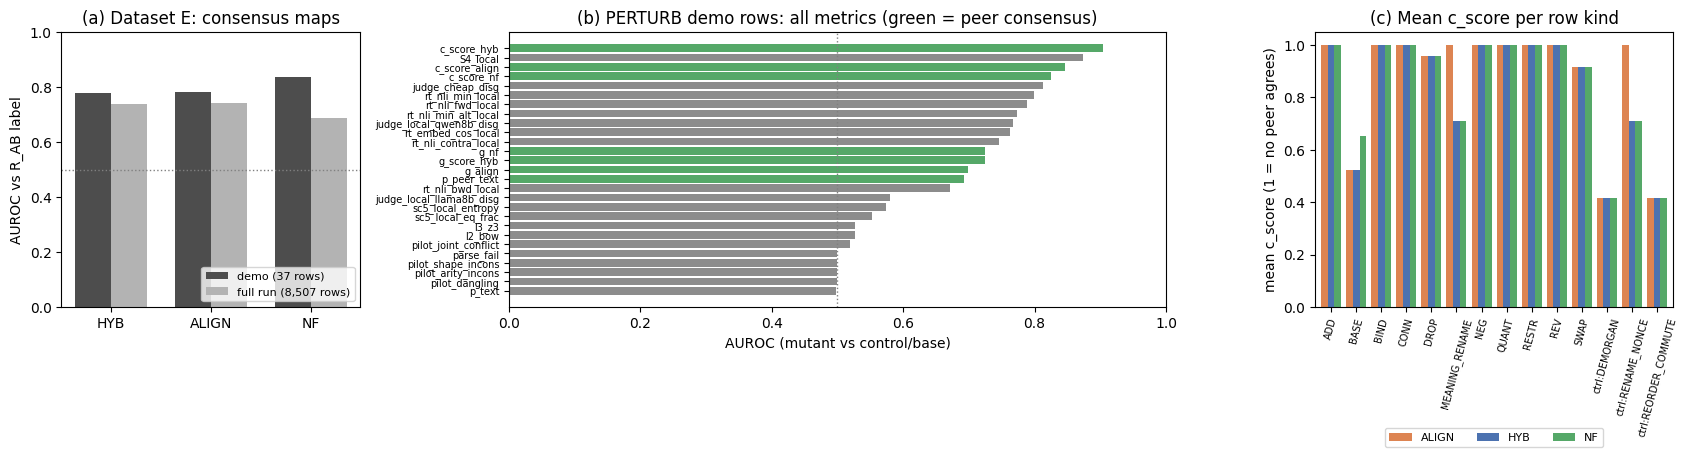

metadata_fold metadata_rewrite_family metadata_probe  output predict_c_score_align predict_c_score_hyb predict_c_score_nf
 REWRITE_EXPD                  RENAME                CORRECT              1.000000            0.400000           0.400000
 REWRITE_EXPD          CONTRAPOSITIVE                CORRECT              0.600000            0.600000           0.600000
 REWRITE_EXPD                 REORDER                CORRECT              0.400000            0.400000           0.400000
 REWRITE_EXPD                DEMORGAN                CORRECT              0.400000            0.400000           0.400000
 REWRITE_EXPD                 REPRINT                  ERROR              0.000000            0.000000           0.000000
 REWRITE_EXPD                  PRENEX                CORRECT              0.000000            0.000000           0.000000
       SCREEN                                        CORRECT              0.400000            0.400000           0.400000
       SCREEN           

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5.2), gridspec_kw={"width_ratios": [1, 2.2, 1.2]})

# (a) E: demo vs full-run AUROC of the three binary consensus maps
names = ["c_score_hyb", "c_score_align", "c_score_nf"]
xs = np.arange(3)
ax[0].bar(xs - 0.18, tabE.loc[names, "demo AUROC (R_AB)"], 0.36, label=f"demo ({len(lab)} rows)", color="#4D4D4D")
ax[0].bar(xs + 0.18, tabE.loc[names, "full-run stratified AUROC"], 0.36, label="full run (8,507 rows)", color="#B3B3B3")
ax[0].axhline(0.5, color="grey", ls=":", lw=1)
ax[0].set_xticks(xs, ["HYB", "ALIGN", "NF"]); ax[0].set_ylim(0, 1); ax[0].set_ylabel("AUROC vs R_AB label")
ax[0].set_title("(a) Dataset E: consensus maps"); ax[0].legend(fontsize=8, loc="lower right")

# (b) PERTURB: demo AUROC for every metric
ax[1].barh(aur.index[::-1], aur.values[::-1], color=["#55A868" if n.startswith(("c_", "g_", "p_peer")) else "#8C8C8C" for n in aur.index[::-1]])
ax[1].axvline(0.5, color="grey", ls=":", lw=1); ax[1].set_xlim(0, 1)
ax[1].set_xlabel("AUROC (mutant vs control/base)"); ax[1].set_title("(b) PERTURB demo rows: all metrics (green = peer consensus)")
ax[1].tick_params(axis="y", labelsize=7)

# (c) rename invariance: c_align flags renamed controls, NF does not (the mechanism behind the Part-A selection)
k = P.groupby("kind")[["predict_c_score_align", "predict_c_score_hyb", "predict_c_score_nf"]].mean()
k.columns = ["ALIGN", "HYB", "NF"]
k.plot.bar(ax=ax[2], width=0.8, color=["#DD8452", "#4C72B0", "#55A868"])
ax[2].set_title("(c) Mean c_score per row kind"); ax[2].set_ylabel("mean c_score (1 = no peer agrees)")
ax[2].tick_params(axis="x", labelsize=7, rotation=75); ax[2].set_xlabel("")
ax[2].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.42), ncol=3)
plt.tight_layout(); plt.show()

# screen / rewrites summary
S = pd.concat([D["expD_rewrites_screen"], D["screen_items_and_probes"]], ignore_index=True)
cols = [c for c in ["metadata_fold", "metadata_rewrite_family", "metadata_probe", "output", "predict_c_score_align", "predict_c_score_hyb", "predict_c_score_nf"] if c in S]
print(S[cols].fillna("").to_string(index=False))